In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/telco_info.csv')

# Convert TotalCharges to numeric (coerce errors if any blanks exist)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges if any
df = df.dropna(subset=['TotalCharges'])

# Map SeniorCitizen for better labels (optional but helpful)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df.shape

(7032, 21)

C:\Users\mifer\AppData\Local\Temp\ipykernel_4204\3693575203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['skyblue', 'salmon'])


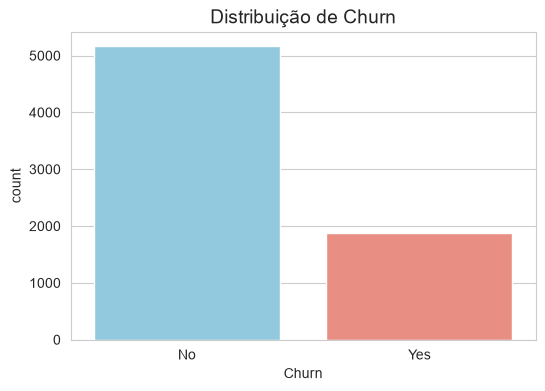

In [4]:
# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['skyblue', 'salmon'])
plt.title('Distribuição de Churn', fontsize=14)
plt.show()

In [5]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

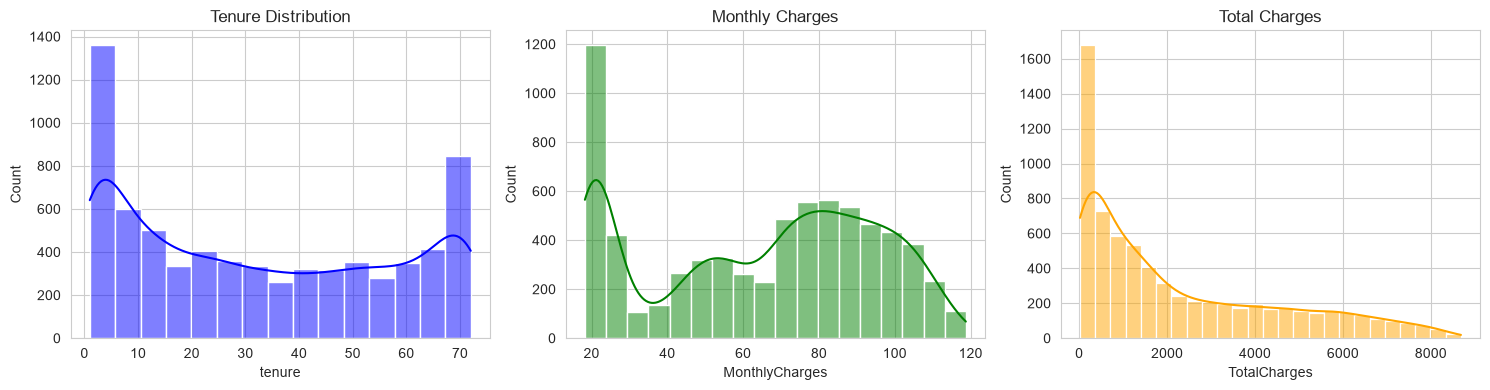

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['tenure'], kde=True, ax=axes[0], color='blue').set_title('Tenure Distribution')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='green').set_title('Monthly Charges')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='orange').set_title('Total Charges')
plt.tight_layout()
plt.show()

In [7]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


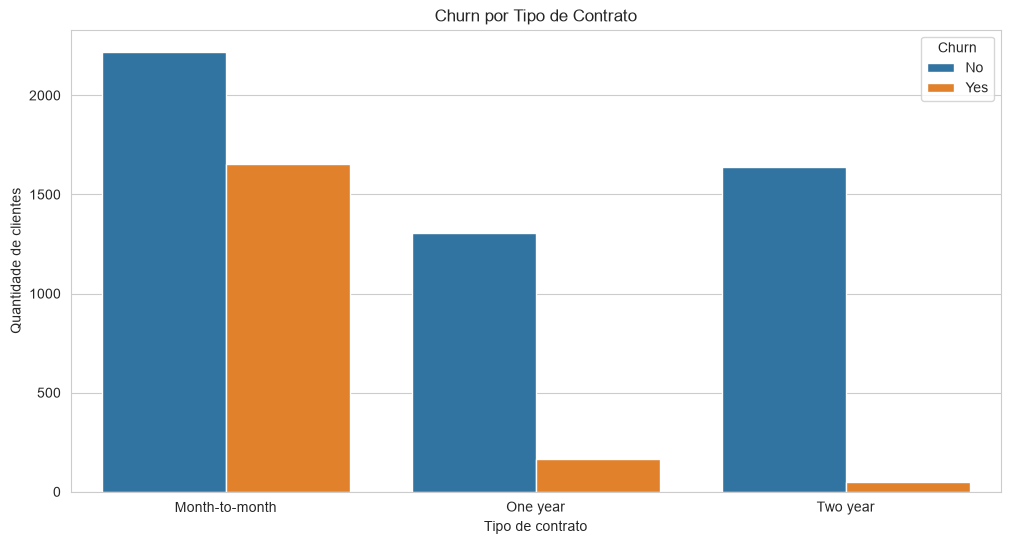

In [8]:
sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Quantidade de clientes')
plt.show()

In [9]:
"""# List of categorical columns to test
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Plot 4 per figure
for i, col in enumerate(cat_cols):
    plt.figure(figsize=(10, 4))
    # Normalize to show percentages within each group
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(
        kind='bar', stacked=True, ax=plt.gca(), color=['skyblue', 'salmon']
    )
    plt.title(f'Churn Rate by {col}', fontsize=14)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Churn', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()"""

"# List of categorical columns to test\ncat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', \n            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', \n            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', \n            'Contract', 'PaperlessBilling', 'PaymentMethod']\n\n# Plot 4 per figure\nfor i, col in enumerate(cat_cols):\n    plt.figure(figsize=(10, 4))\n    # Normalize to show percentages within each group\n    pd.crosstab(df[col], df['Churn'], normalize='index').plot(\n        kind='bar', stacked=True, ax=plt.gca(), color=['skyblue', 'salmon']\n    )\n    plt.title(f'Churn Rate by {col}', fontsize=14)\n    plt.ylabel('Proportion')\n    plt.xticks(rotation=45)\n    plt.legend(title='Churn', bbox_to_anchor=(1, 1))\n    plt.tight_layout()\n    plt.show()"

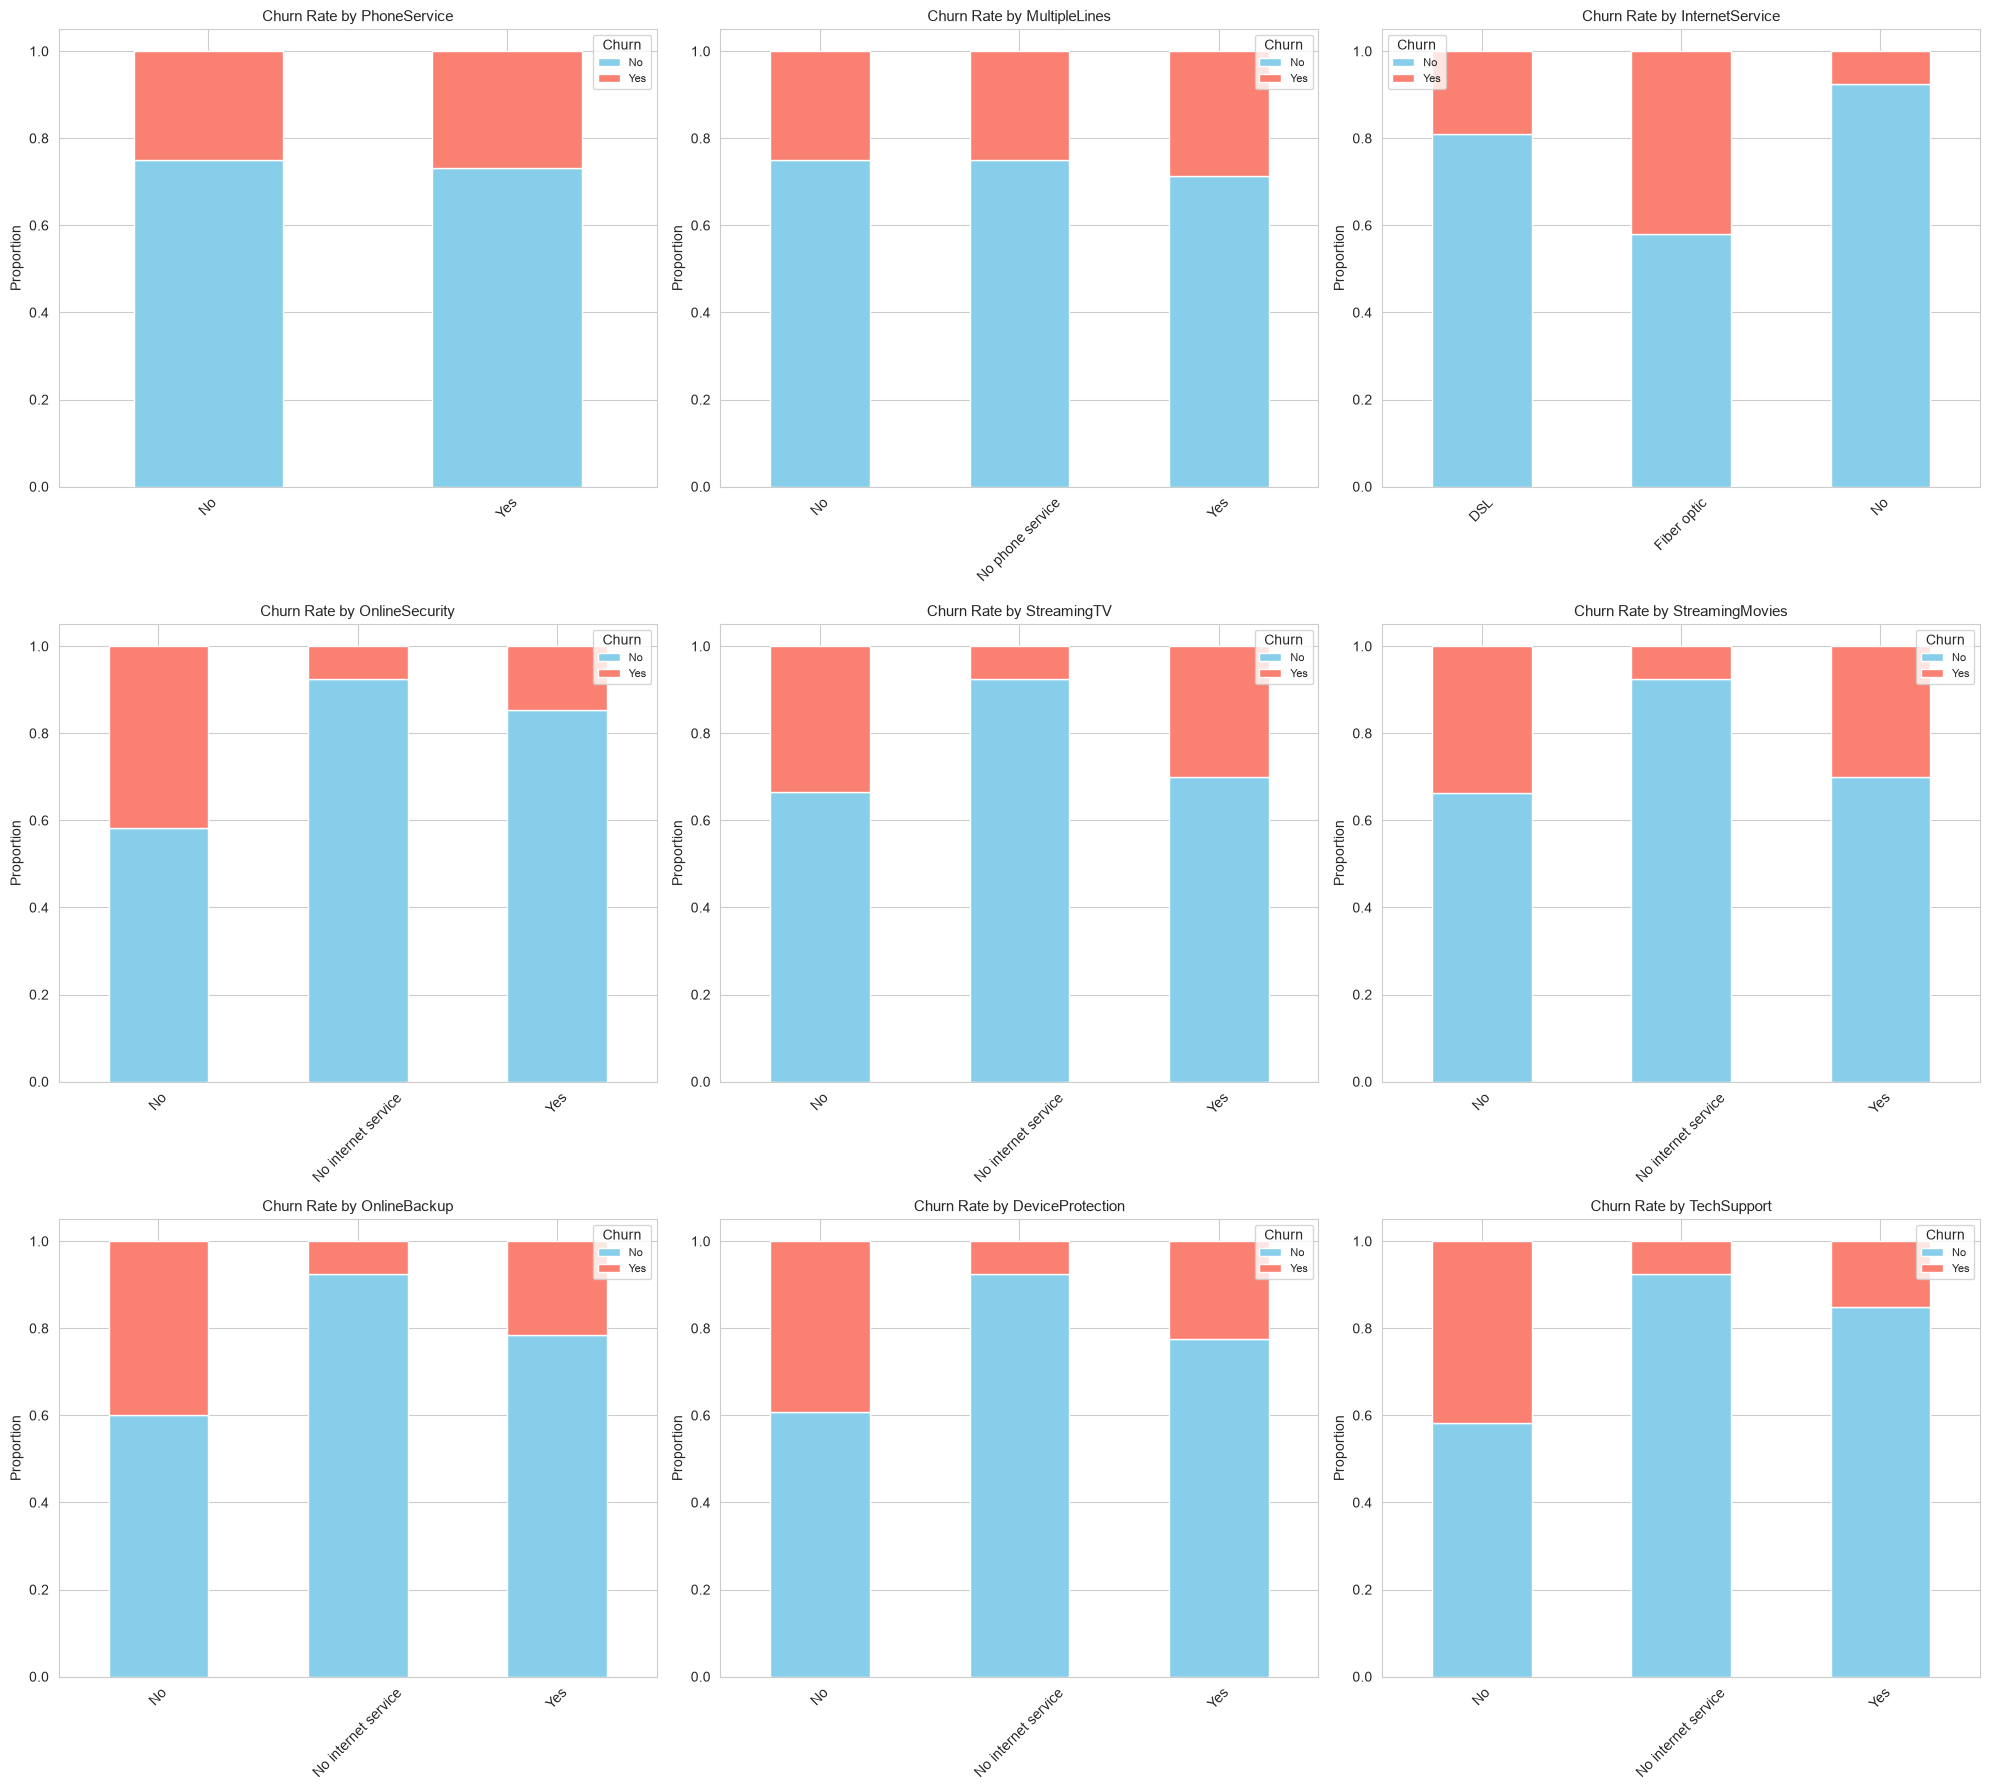

In [10]:
# Lista de colunas categóricas
cols_payment = [
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
cols_demo = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
cols_service = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity','StreamingTV', 
    'StreamingMovies', 'OnlineBackup', 'DeviceProtection', 'TechSupport']


fig, axes = plt.subplots(3,3, figsize=(20, 18))

# Transformar a matriz de eixos em uma lista
axes = axes.flatten()

for i, col in enumerate(cols_service):

    # Calcular proporção de Churn dentro de cada categoria
    crosstab = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    )

    # Plotar no eixo correspondente
    crosstab.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=['skyblue', 'salmon']
    )

    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn', fontsize=8)
plt.tight_layout()

plt.show()

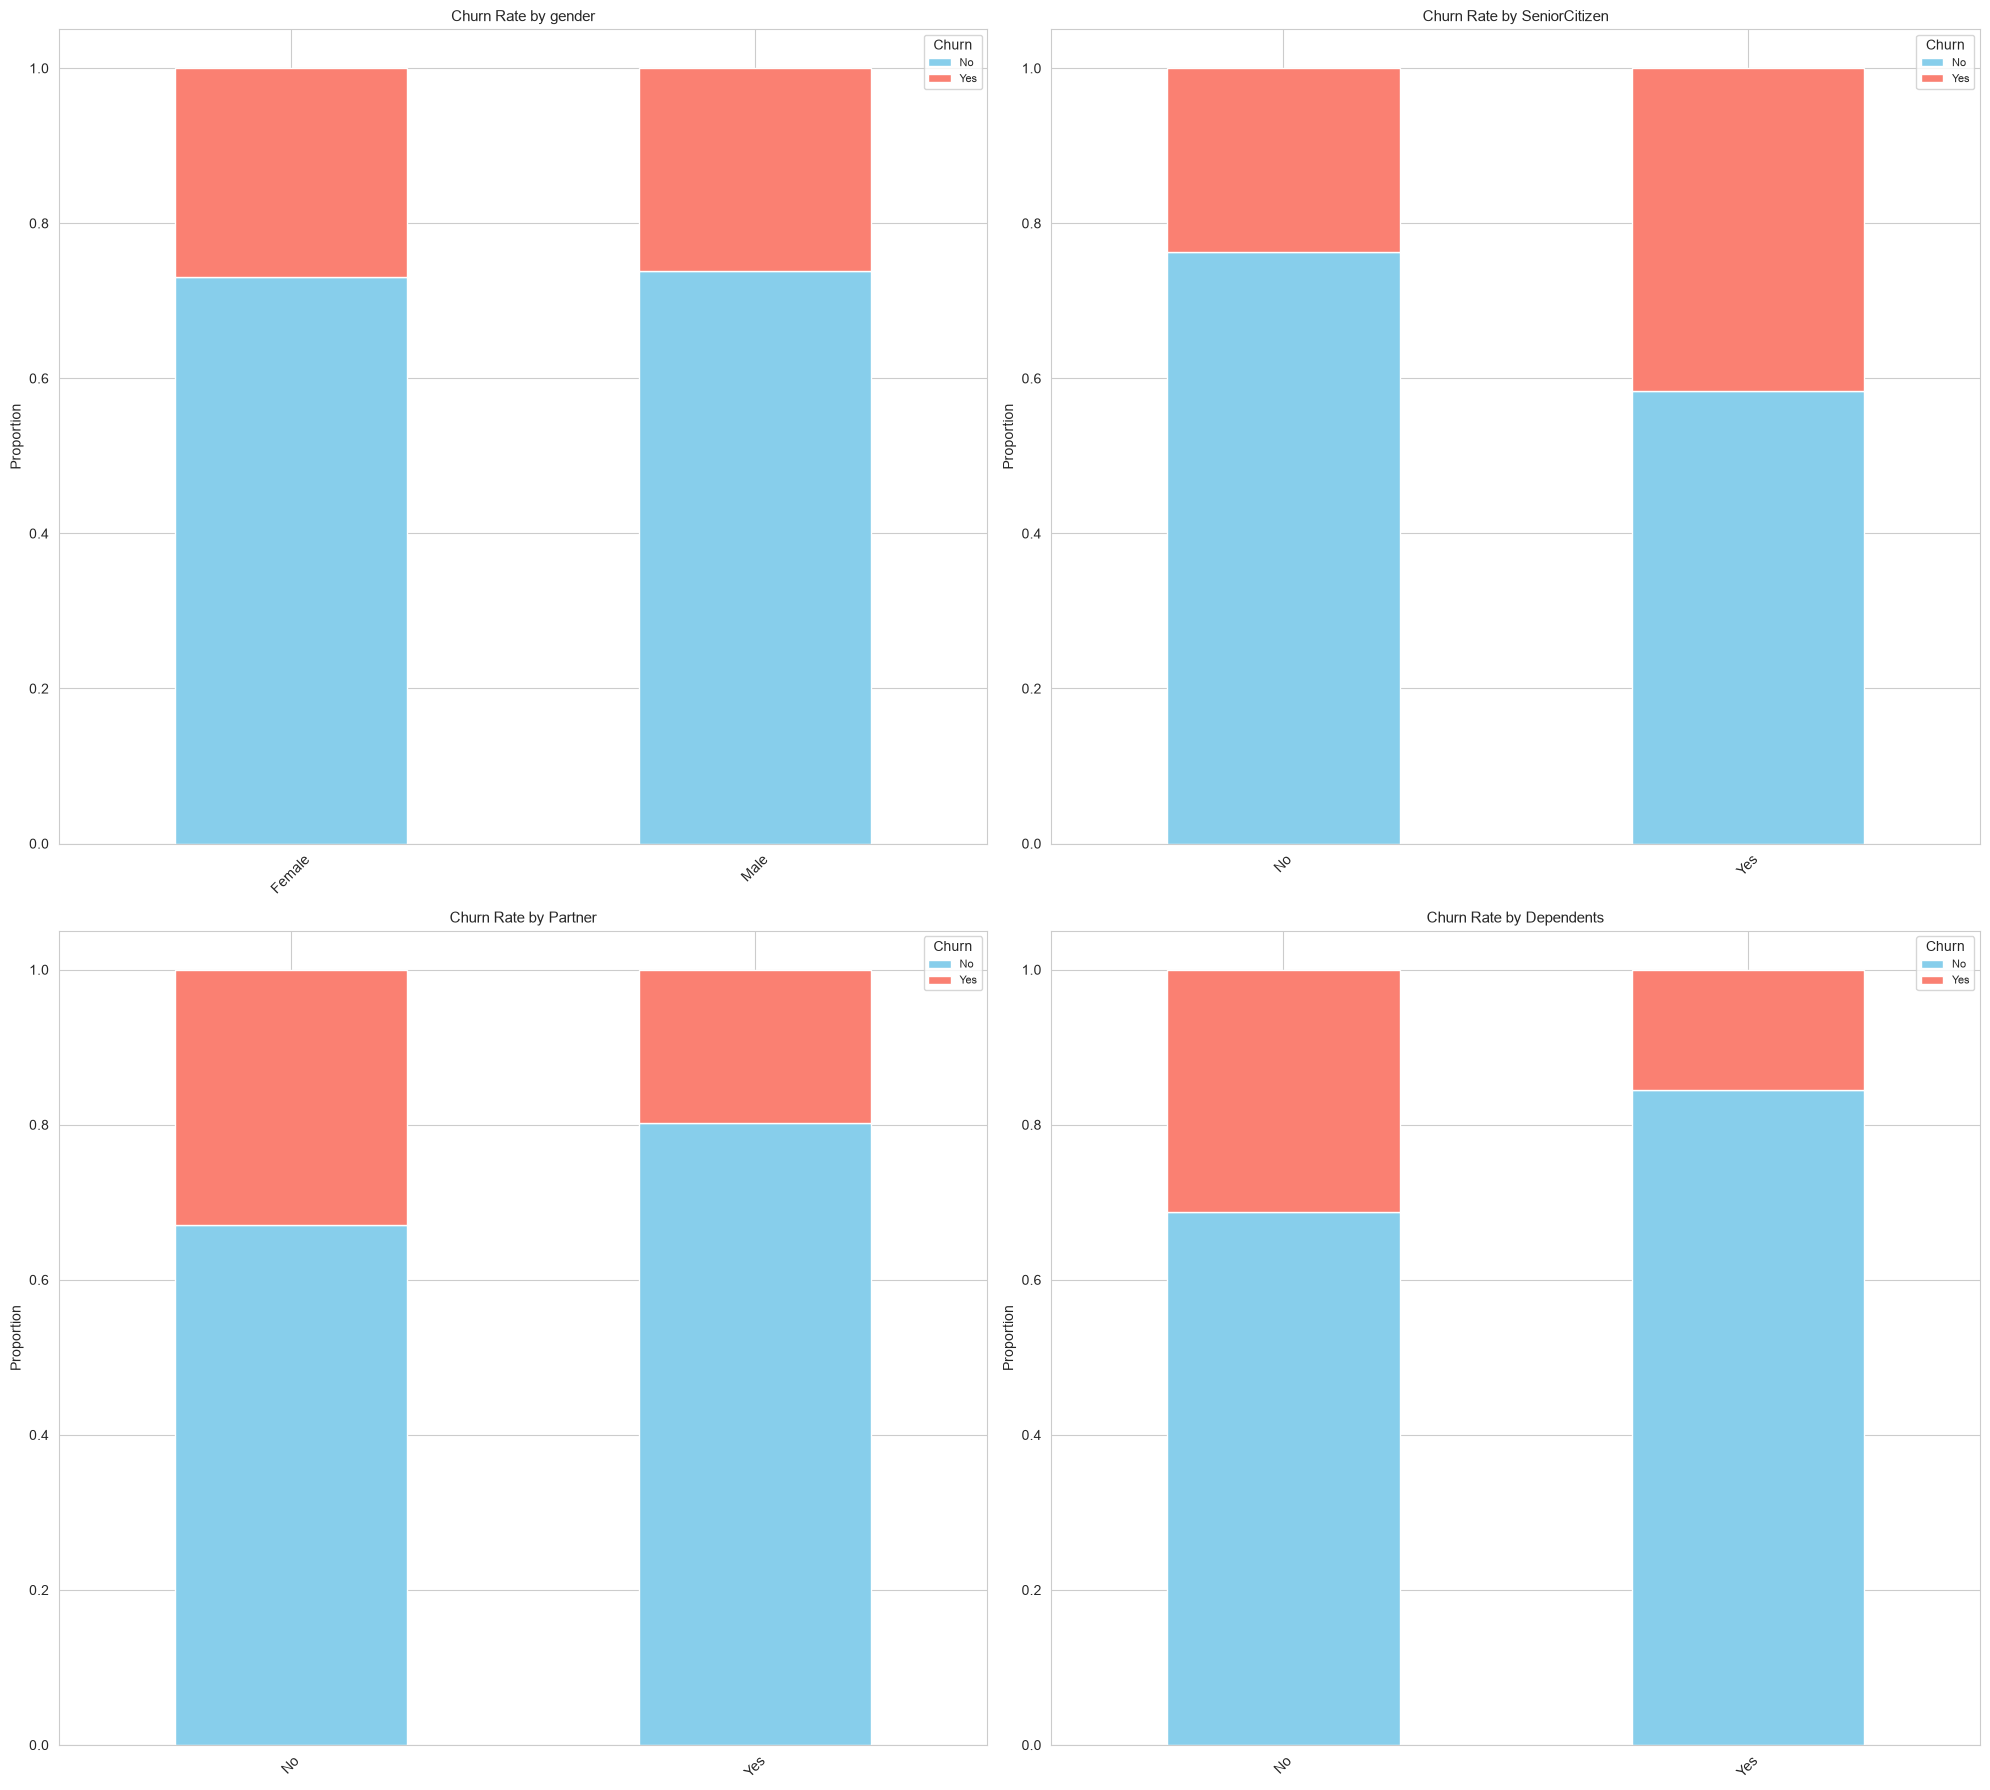

In [11]:
fig, axes = plt.subplots(2,2, figsize=(20, 18))

# Transformar a matriz de eixos em uma lista
axes = axes.flatten()

for i, col in enumerate(cols_demo):

    # Calcular proporção de Churn dentro de cada categoria
    crosstab = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    )

    # Plotar no eixo correspondente
    crosstab.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=['skyblue', 'salmon']
    )

    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn', fontsize=8)

# Ajustar espaçamento
plt.tight_layout()

# Mostrar tudo em uma única figura
plt.show()

In [12]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [13]:
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
SeniorCitizen,,
No,76.349745,23.650255
Yes,58.318739,41.681261


In [14]:
pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


In [15]:
pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


C:\Users\mifer\AppData\Local\Temp\ipykernel_4204\1673960688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette=['skyblue', 'salmon'])
C:\Users\mifer\AppData\Local\Temp\ipykernel_4204\1673960688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette=['skyblue', 'salmon'])
C:\Users\mifer\AppData\Local\Temp\ipykernel_4204\1673960688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], pal

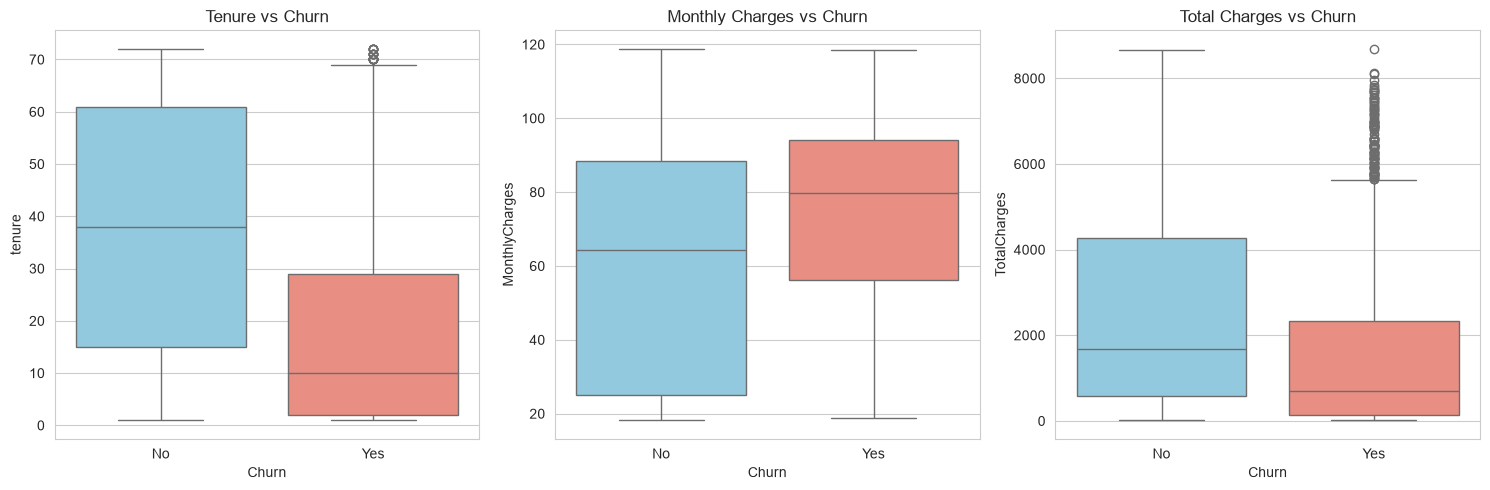

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette=['skyblue', 'salmon'])
axes[0].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette=['skyblue', 'salmon'])
axes[1].set_title('Monthly Charges vs Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette=['skyblue', 'salmon'])
axes[2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

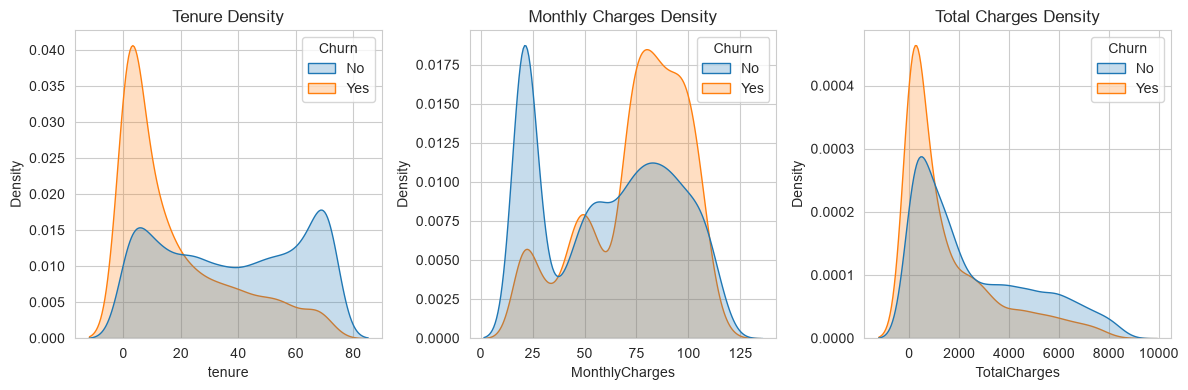

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Tenure Density')

plt.subplot(1,3,2)
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Monthly Charges Density')

plt.subplot(1,3,3)
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Total Charges Density')

plt.tight_layout()
plt.show()

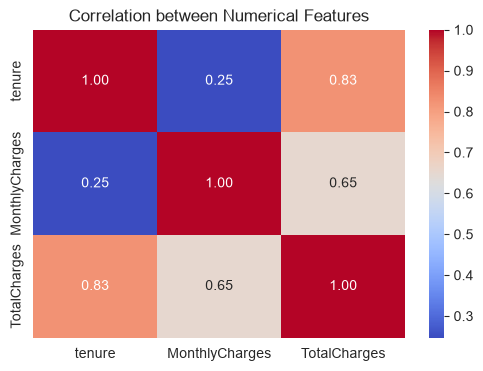

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Numerical Features')
plt.show()

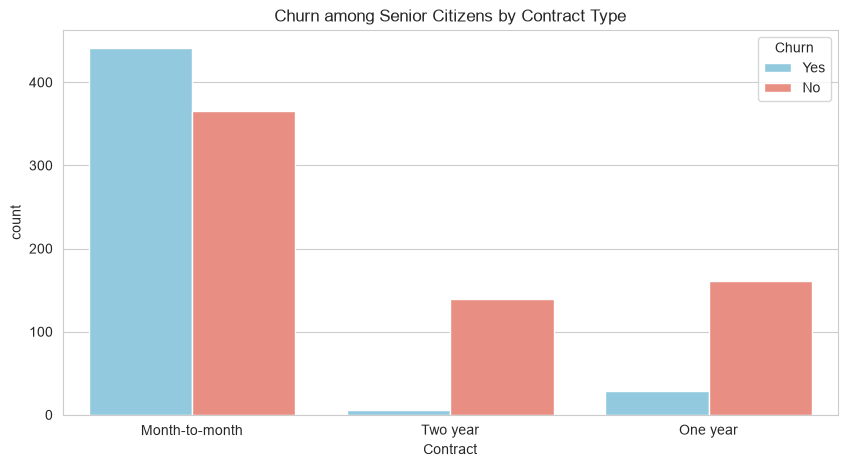

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df[df['SeniorCitizen'] == 'Yes'], palette=['skyblue', 'salmon'])
plt.title('Churn among Senior Citizens by Contract Type')
plt.show()

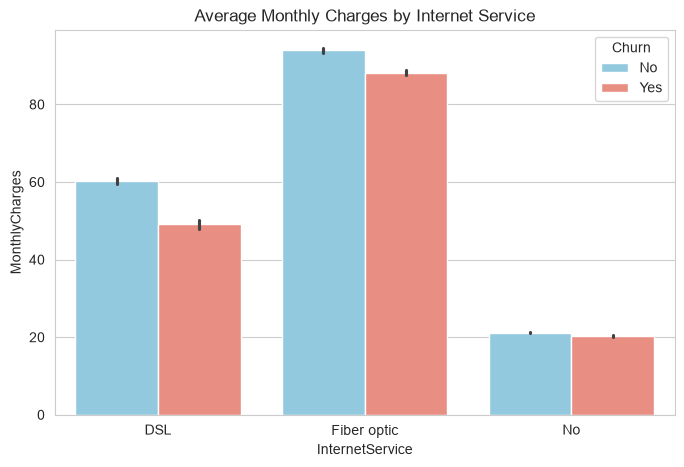

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x='InternetService', y='MonthlyCharges', hue='Churn', data=df, palette=['skyblue', 'salmon'])
plt.title('Average Monthly Charges by Internet Service')
plt.show()

C:\Users\mifer\AppData\Local\Temp\ipykernel_4204\1982839621.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Contract', y='tenure', data=df, palette='Set2')


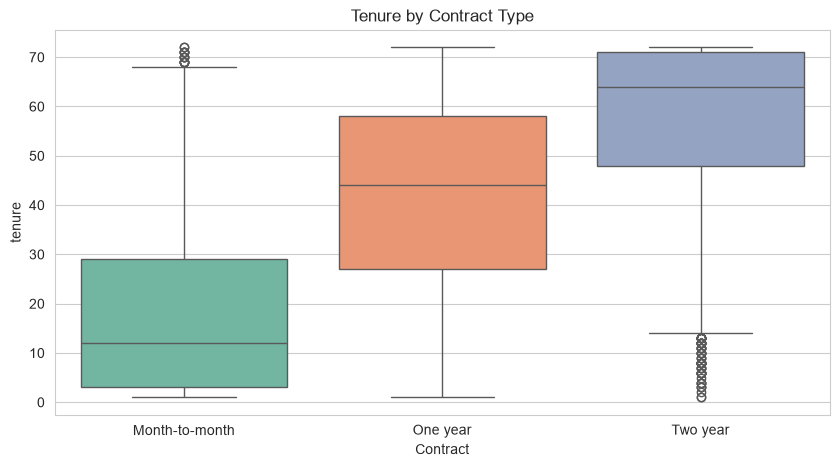

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Contract', y='tenure', data=df, palette='Set2')
plt.title('Tenure by Contract Type')
plt.show()

<Figure size 1000x500 with 0 Axes>

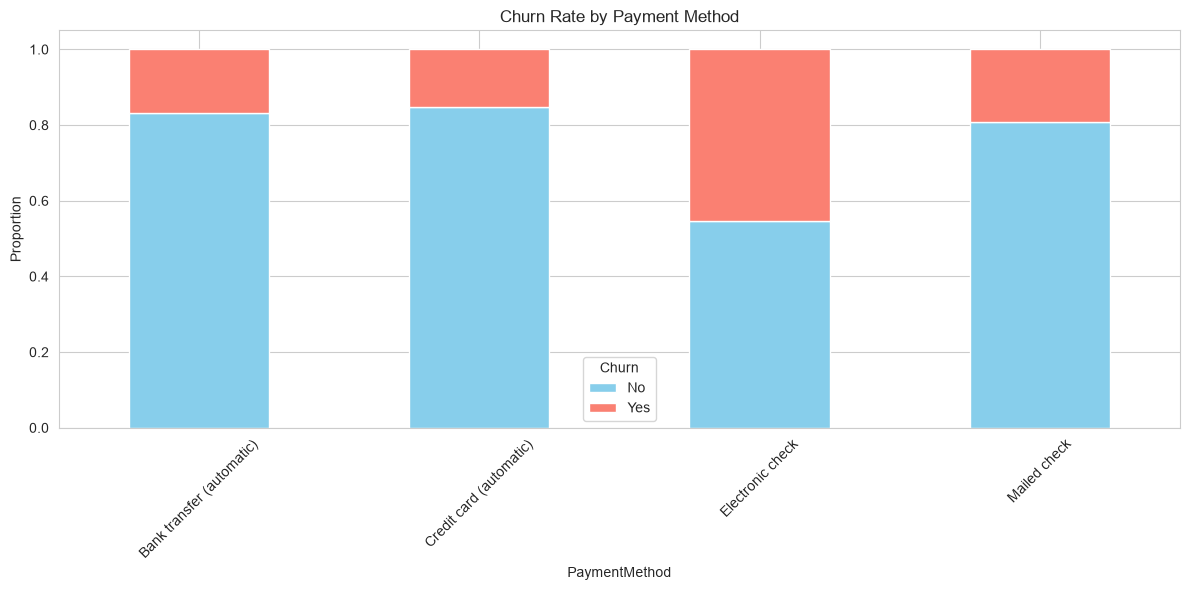

In [22]:
plt.figure(figsize=(10,5))
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Churn Rate by Payment Method')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

NameError: name 'cat_cols' is not defined

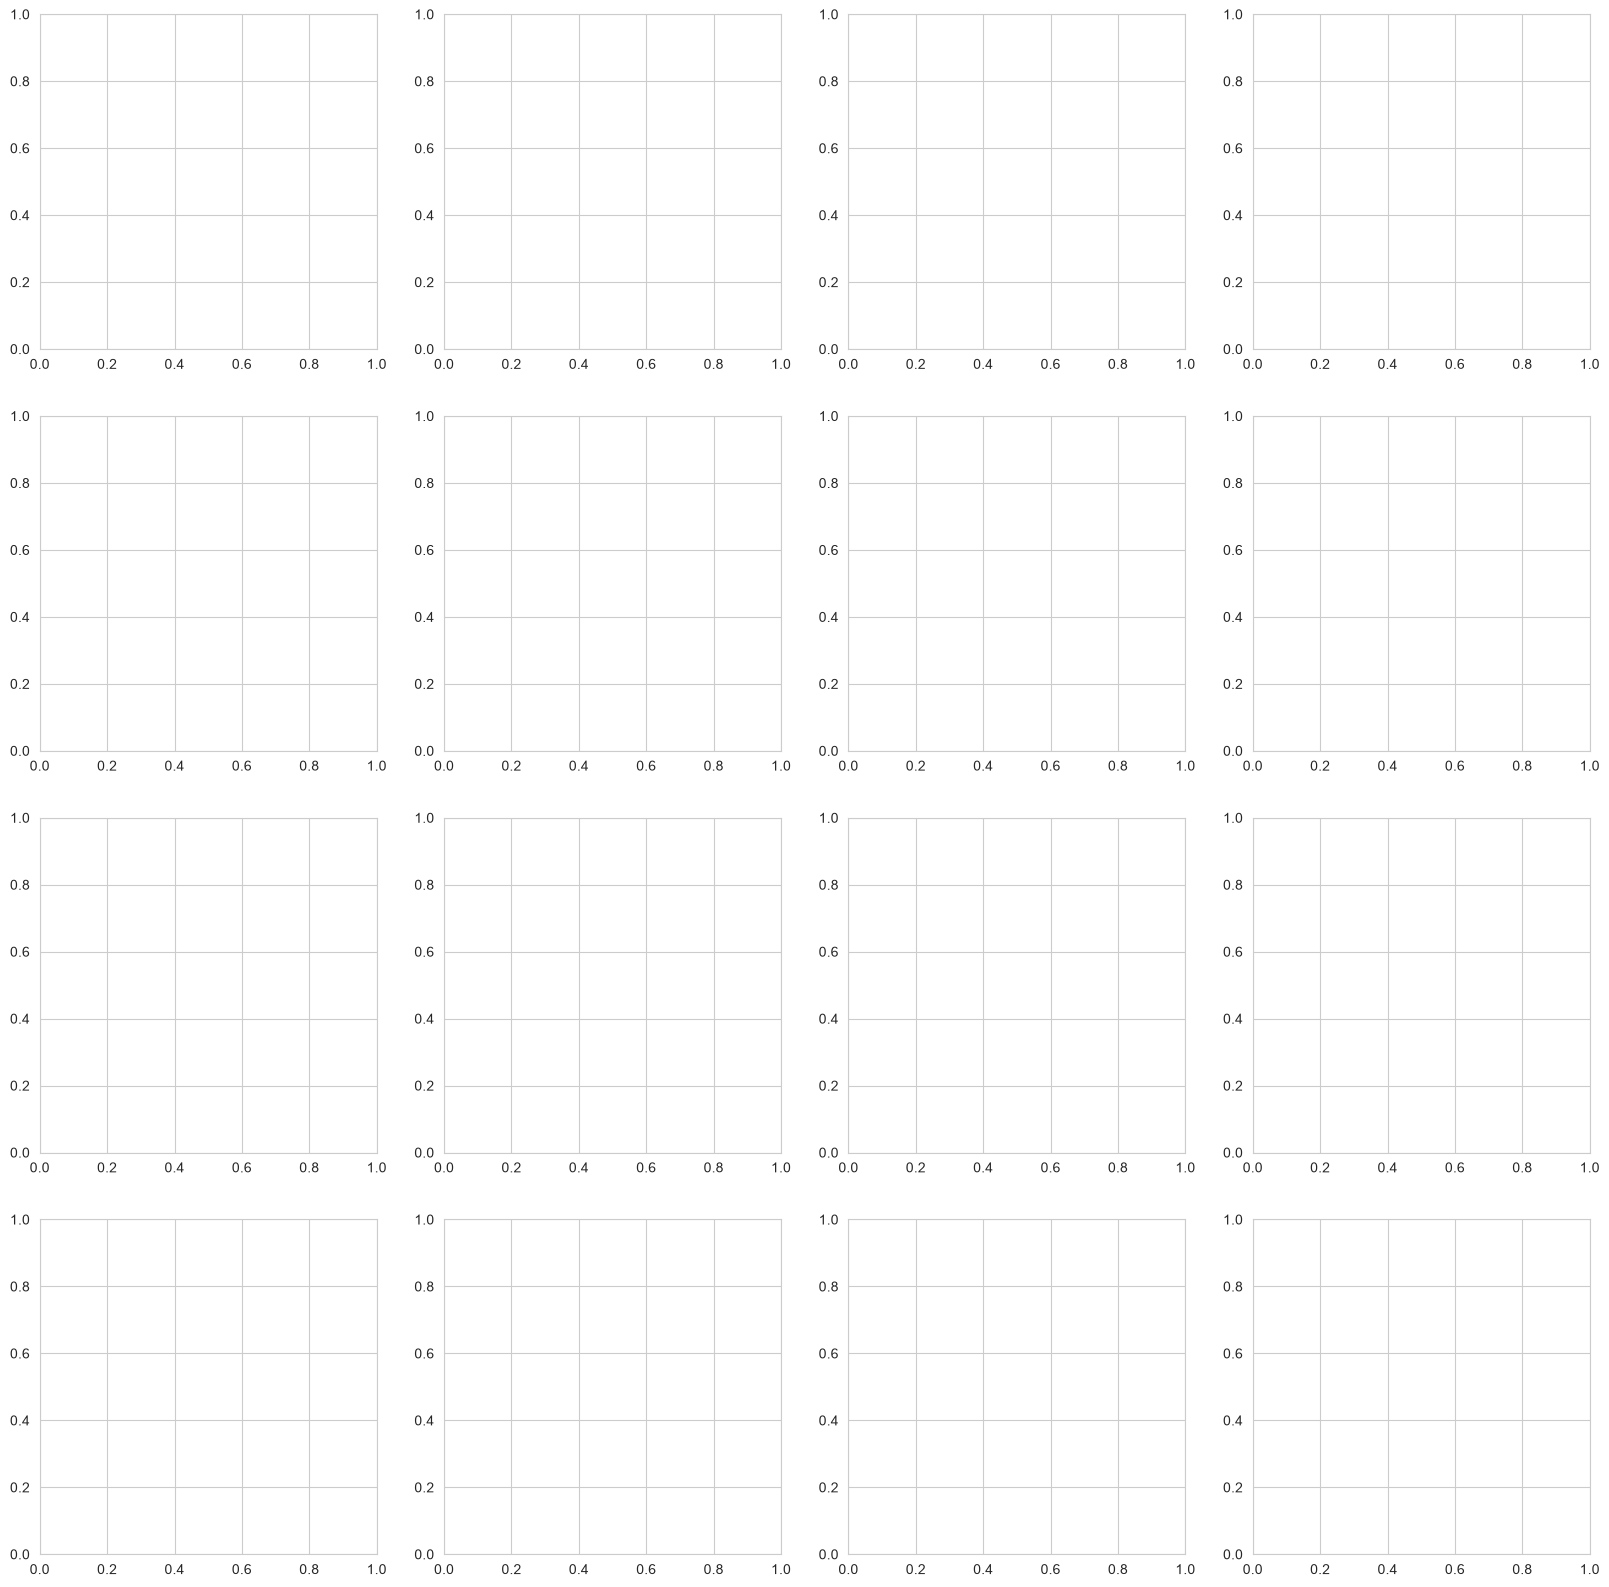

In [23]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(kind='bar', stacked=True, ax=axes[i], color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(col)
    axes[i].legend().remove()
plt.tight_layout()
plt.show()

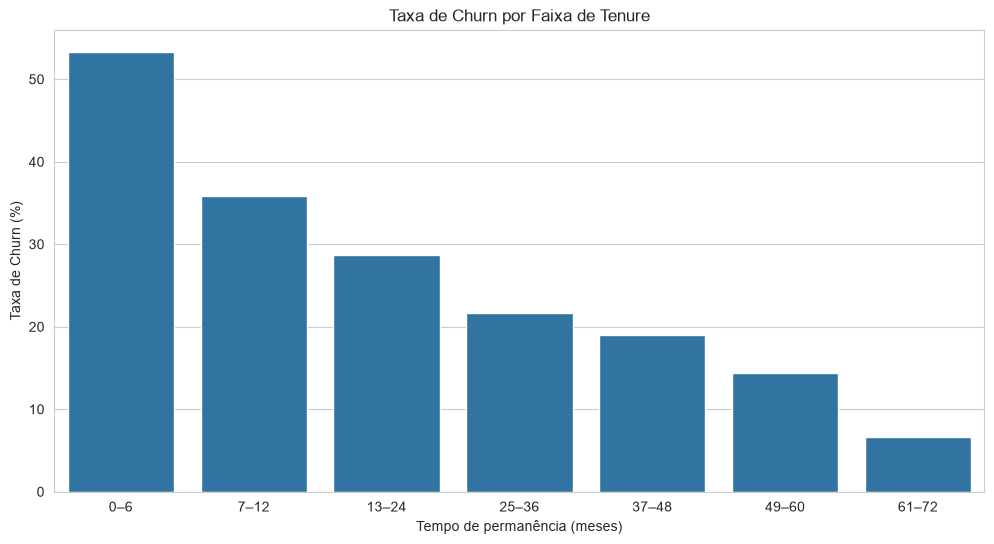

In [ ]:
bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0–6', '7–12', '13–24', '25–36', '37–48', '49–60', '61–72']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

churn_by_group = (
    df.groupby('tenure_group', observed=True)['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='ChurnRate')
)

sns.barplot(
    data=churn_by_group,
    x='tenure_group',
    y='ChurnRate'
)

plt.title('Taxa de Churn por Faixa de Tenure')
plt.xlabel('Tempo de permanência (meses)')
plt.ylabel('Taxa de Churn (%)')
plt.show()

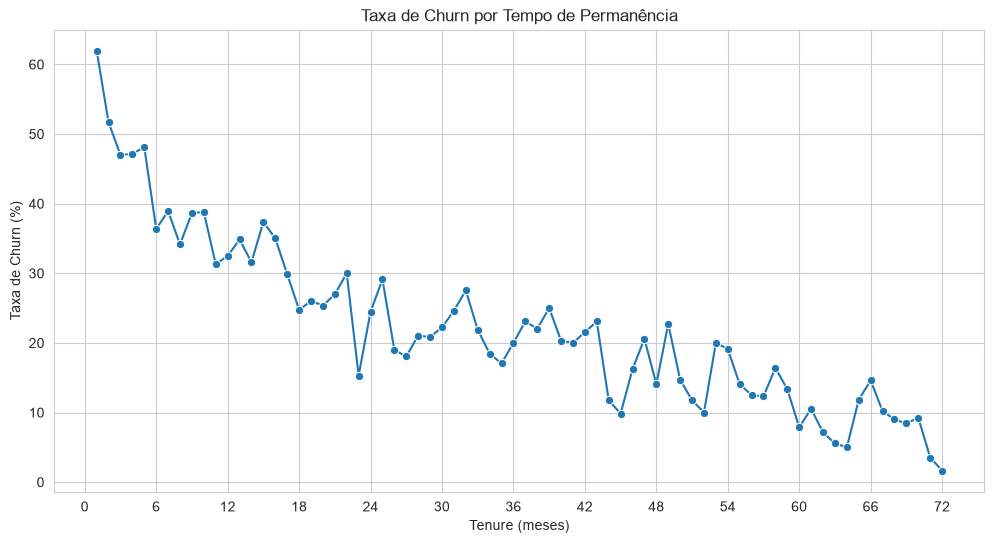

In [ ]:
churn_by_tenure = (
    df.groupby('tenure')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='ChurnRate')
)

sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=churn_by_tenure,
    x='tenure',
    y='ChurnRate',
    marker='o'
)

plt.title('Taxa de Churn por Tempo de Permanência')
plt.xlabel('Tenure (meses)')
plt.ylabel('Taxa de Churn (%)')
plt.xticks(range(0, 73, 6))
plt.show()